# Importing Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

In [32]:
df = pd.read_csv("house_price_dataset.csv")
df.head()

,size_sqft,bedrooms,age,distance_city_km,price
0,1699,4,18,6.7,216099
1,1445,1,4,16.1,138683
2,1759,3,10,10.3,182414
3,2109,5,11,16.6,257062
4,1406,3,9,7.0,173768


# Quick inspection & cleaning

In [33]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())
print("\nData types:\n", df.dtypes)
print("\nPrice statistics:\n", df['price'].describe())

# Show suspicious low/negative prices
print("\nVery low or negative prices:")
print(df[df['price'] < 20000][['size_sqft','bedrooms','age','distance_city_km','price']])

# Remove unrealistic prices (negative or extremely low)
df_clean = df[df['price'] > 20000].copy()

print(f"\nOriginal rows: {len(df)} → After cleaning: {len(df_clean)}")

Shape: (1000, 5)

Missing values:
 size_sqft           0
bedrooms            0
age                 0
distance_city_km    0
price               0
dtype: int64

Data types:
 size_sqft             int64
bedrooms              int64
age                   int64
distance_city_km    float64
price                 int64
dtype: object

Price statistics:
 count      1000.000000
mean     161429.873000
std       56702.912334
min       -8609.000000
25%      123621.750000
50%      159637.000000
75%      199212.500000
max      353206.000000
Name: price, dtype: float64

Very low or negative prices:
     size_sqft  bedrooms  age  distance_city_km  price
429        797         1   12              19.4    599
575        616         5   39              14.0  -8609
646        421         1    4              18.5  19095
668        440         2   32               9.6    477
749        937         4   37              15.2  13855
977        530         4   39              11.6  18488

Original rows: 1000 → Afte

# Define features & target

In [34]:
features = ['size_sqft', 'bedrooms', 'age', 'distance_city_km']
target   = 'price'

X = df_clean[features].copy()
y = df_clean[target].copy()

print("Features:", features)
print("Target:  ", target)

Features: ['size_sqft', 'bedrooms', 'age', 'distance_city_km']
Target:   price


# Train-test split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print(f"Train: {X_train.shape[0]} rows")
print(f" Test: {X_test.shape[0]} rows")

Train: 745 rows
 Test: 249 rows


# Scale numerical features + train model

In [36]:
scaler = StandardScaler()

# Fit scaler on training data only
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train linear regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model trained ✓")

Model trained ✓


# Evaluate the model

In [37]:
y_pred = model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Linear Regression — House Price Prediction")
print("─────────────────────────────────────────")
print(f"MAE:  {mae:,.0f} $")
print(f"RMSE: {rmse:,.0f} $")
print(f"R²:   {r2:.3f}  ({r2*100:.1f}%)")

Linear Regression — House Price Prediction
─────────────────────────────────────────
MAE:  15,461 $
RMSE: 19,064 $
R²:   0.894  (89.4%)


# Show coefficients (feature importance)

In [38]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).round(2)

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')

print("Model Coefficients:")
print(coef_df.to_string(index=False))

Model Coefficients:
         Feature  Coefficient
       size_sqft     44468.30
             age    -16759.76
        bedrooms     13860.95
distance_city_km     -9524.74


# Actual vs Predicted plot

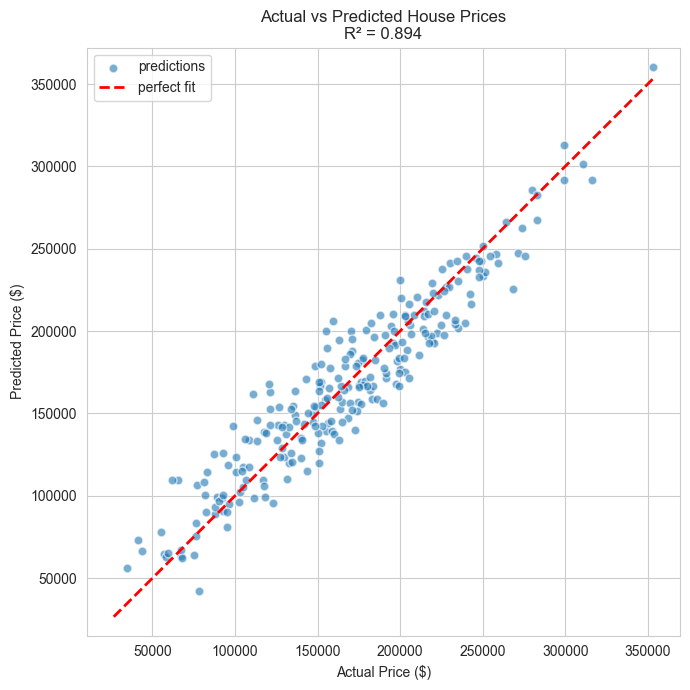

In [39]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6, s=40, edgecolor='white', label='predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='perfect fit')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Actual vs Predicted House Prices\nR² = {r2:.3f}')
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

# Predict price for a new house

In [40]:
# Example new house
new_house = pd.DataFrame({
    'size_sqft':         [1800],
    'bedrooms':          [3],
    'age':               [12],
    'distance_city_km':  [7.5]
})

new_house_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_house_scaled)[0]

print(f"Predicted price: ${predicted_price:,.0f}")

Predicted price: $212,286
